In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import itertools
from itertools import permutations
#from itertools import combinations
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
import pubchempy
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

from itertools import islice
import seaborn as sns
import random


In [2]:

def running_average(file):
  running_ave = np.zeros(( len(file[:,0]) , len(file[0,:]) ))
  for i in range(len(file[0,:])):
        for j in range(len(file[:,0])): 
            mov_average = np.mean(file[0:j+1,i])
            running_ave[j,i] = mov_average
  return(running_ave)


In [3]:

mol_alkanes_sameTr = np.array([  "dodecane_38_310_335.68",
 "undecane_35_330_325.89",
 "decane_32_340_315.08",
 "nonane_29_380_303.45",
 "octane_26_430_290.04",
 "heptane_23_490_275.40",
 "hexane_20_550_258.88",
 "pentane_17_700_239.60",
 "butane_14_850_216.75", 
 "propane_11_1000_188.65",
 "ethane_8_1500_155.70",
 "methane_5_2200_97.21"
  ])
                      

In [5]:

def extract_hfdcorr_data(input_df, ehex_id):
    
    mol_t = input_df.iloc[:, 0]
    mol_t = mol_t.to_numpy()
    exp_data = input_df.iloc[:, 1]
    exp_unc = input_df.iloc[:, 2]
    num_sites = input_df.iloc[:, 3]
    num_h_atoms = input_df.iloc[:, 4]
    num_non_h_sites = num_sites - num_h_atoms
    
    
    mol_calibrate_time = mol_t[0]
    heatflux_decompose_time = open(f'avefluxes_one_ce_left.{mol_calibrate_time}_reshape_HFD.{ehex_id}.profile')
    ext_heatflux_time = []
    for line in heatflux_decompose_time:
        ext_heatflux_time_1 = ((line.split(' ')[0]))
        ext_heatflux_time = np.append(ext_heatflux_time, ext_heatflux_time_1)
    ext_heatflux_time = np.array(ext_heatflux_time)
    ext_heatflux_time = ext_heatflux_time[2:]
    ext_heatflux_time = ext_heatflux_time.astype(float)

    run_avg_start_index = int((len(ext_heatflux_time))/2)
    
    ext_heatflux_convective = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_coulombic = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_bond = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_angle = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_dihedral = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_pair = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_total = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_imposed = np.zeros((run_avg_start_index, len(mol_t)))
    #-------------------- heat fluxes with centroid approach --------------
    ext_heatflux_ce_angle = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_ce_bond = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_ce_dihedral = np.zeros((run_avg_start_index, len(mol_t)))
    ext_heatflux_ce_pair = np.zeros((run_avg_start_index, len(mol_t)))
    

    for i in range(len(mol_t)):
        #print(mol_t[i])
        
        with open(f"avefluxes_one_left.{mol_t[i]}_reshape_HFD.{ehex_id}.profile") as file_1:
        
            heatflux_decompose_output = islice(file_1, 2, None)
            
            ext_heatflux_imposed_pertemp = []
            ext_heatflux_total_pertemp = []
            ext_heatflux_coulombic_pertemp = []
            ext_heatflux_convective_pertemp = []
            ext_heatflux_angle_pertemp = []
            ext_heatflux_bond_pertemp = []
            ext_heatflux_dihedral_pertemp = []
            ext_heatflux_pair_pertemp = []
            
            for line in heatflux_decompose_output:
                 
                ext_heatflux_imposed_1 = ((line.split()[8]))
                ext_heatflux_imposed_pertemp.append(float(ext_heatflux_imposed_1))
        
                ext_heatflux_total_1 = ((line.split()[7]))
                ext_heatflux_total_pertemp.append(float(ext_heatflux_total_1))
        
                ext_heatflux_coulombic_1 = ((line.split()[6]))
                ext_heatflux_coulombic_pertemp.append(float(ext_heatflux_coulombic_1))
        
                ext_heatflux_convective_1 = ((line.split()[1]))
                ext_heatflux_convective_pertemp.append(float(ext_heatflux_convective_1))
                
                ext_heatflux_angle_1 = ((line.split()[2]))
                ext_heatflux_angle_pertemp.append(float(ext_heatflux_angle_1))
                
                ext_heatflux_bond_1 = ((line.split()[3]))
                ext_heatflux_bond_pertemp.append(float(ext_heatflux_bond_1))
                
                ext_heatflux_dihedral_1 = ((line.split()[4]))
                ext_heatflux_dihedral_pertemp.append(float(ext_heatflux_dihedral_1))
                
                ext_heatflux_pair_1 = ((line.split()[5]))
                ext_heatflux_pair_pertemp.append(float(ext_heatflux_pair_1))
        
        
        with open(f"avefluxes_one_ce_left.{mol_t[i]}_reshape_HFD.{ehex_id}.profile") as file_2:
        
            heatflux_decompose_output_ce = islice(file_2, 2, None)
            
            ext_heatflux_ce_angle_pertemp = []
            ext_heatflux_ce_bond_pertemp = []
            ext_heatflux_ce_dihedral_pertemp = []
            ext_heatflux_ce_pair_pertemp = []
            
            for line in heatflux_decompose_output_ce:
                 
                ext_heatflux_ce_pair_1 = ((line.split()[-2]))
                ext_heatflux_ce_pair_pertemp.append(float(ext_heatflux_ce_pair_1))
        
                ext_heatflux_ce_dihedral_1 = ((line.split()[-3]))
                ext_heatflux_ce_dihedral_pertemp.append(float(ext_heatflux_ce_dihedral_1))
        
                ext_heatflux_ce_bond_1 = ((line.split()[-4]))
                ext_heatflux_ce_bond_pertemp.append(float(ext_heatflux_ce_bond_1))
        
                ext_heatflux_ce_angle_1 = ((line.split()[-5]))
                ext_heatflux_ce_angle_pertemp.append(float(ext_heatflux_ce_angle_1))
    
        ext_heatflux_coulombic[:,i] =  ext_heatflux_coulombic_pertemp[run_avg_start_index:]
        ext_heatflux_convective[:,i] =  ext_heatflux_convective_pertemp[run_avg_start_index:]
        ext_heatflux_imposed[:,i] =  ext_heatflux_imposed_pertemp[run_avg_start_index:]
        ext_heatflux_total[:,i] =  ext_heatflux_total_pertemp[run_avg_start_index:]
        
        ext_heatflux_pair[:,i] =  ext_heatflux_pair_pertemp[run_avg_start_index:]
        ext_heatflux_dihedral[:,i] =  ext_heatflux_dihedral_pertemp[run_avg_start_index:]
        ext_heatflux_bond[:,i] =  ext_heatflux_bond_pertemp[run_avg_start_index:]
        ext_heatflux_angle[:,i] =  ext_heatflux_angle_pertemp[run_avg_start_index:]
    
        ext_heatflux_ce_pair[:,i] =  ext_heatflux_ce_pair_pertemp[run_avg_start_index:]
        ext_heatflux_ce_dihedral[:,i] =  ext_heatflux_ce_dihedral_pertemp[run_avg_start_index:]
        ext_heatflux_ce_bond[:,i] =  ext_heatflux_ce_bond_pertemp[run_avg_start_index:]
        ext_heatflux_ce_angle[:,i] =  ext_heatflux_ce_angle_pertemp[run_avg_start_index:]
    
    
    a = (running_average(ext_heatflux_imposed))
    b = (running_average(ext_heatflux_total))
    c = (running_average(ext_heatflux_coulombic))
    d = (running_average(ext_heatflux_ce_pair))
    e = (running_average(ext_heatflux_ce_dihedral))
    f = (running_average(ext_heatflux_ce_bond))
    g =  (running_average(ext_heatflux_ce_angle))
    h = (running_average(ext_heatflux_convective))
    
    v = (running_average(ext_heatflux_pair))
    w = (running_average(ext_heatflux_dihedral))
    x = (running_average(ext_heatflux_bond))
    y =  (running_average(ext_heatflux_angle))
    
    # ----- compute corrected total heat flux using centroid approach for bonded contributions --------
    z =  b - w + e - x + f -y + g 
    
    conv_fac = 6.9502 * 10**14
    scale_fac = 1e-9

    fin_imposed = a[-1, :]
    fin_total_ce = z[-1, :]
    fin_bond = f[-1, :]
    fin_angle = g[-1, :]
    fin_dihed = e[-1, :]
    fin_vdwCoul = c[-1, :] + d[-1, :] 
    fin_convec = h[-1, :]
    fin_total = fin_bond + fin_angle + fin_dihed + fin_vdwCoul + fin_convec
    frac_bond = fin_bond/fin_imposed
    frac_angle = fin_angle/fin_imposed
    frac_dihed = fin_dihed/fin_imposed
    frac_vdwCoul = fin_vdwCoul/fin_imposed
    frac_convec = fin_convec/fin_imposed
    
    tc_md = []
    tc_md_err = []
    for j in range(len(mol_t)):
        tc = np.loadtxt(f"kappa_value_{mol_t[j]}.txt")
        tc_md.append(tc)
        tc_err = np.loadtxt(f"kappa_value_abserror_{mol_t[j]}.txt")
        tc_md_err.append(tc_err)
    tc_md = np.array(tc_md).flatten()
    tc_md_err = np.array(tc_md_err).flatten()
   
    frac_over = (tc_md - exp_data)/exp_data
    
    x1_data = frac_bond
    x2_data = frac_angle
    x3_data = frac_dihed
    y_data = frac_over
    
    return frac_bond, frac_angle, frac_dihed, frac_over, tc_md, tc_md_err, exp_data, exp_unc, num_sites, num_h_atoms, num_non_h_sites, frac_vdwCoul, frac_convec, fin_total, fin_total_ce, fin_imposed         
    
    
    


In [6]:

tc_hfd_training = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="data_tc_hfd_train")


In [7]:
%%time
tc_hfd_extracted_train =   extract_hfdcorr_data(tc_hfd_training.iloc[0:,:], 0.003)


CPU times: total: 219 ms
Wall time: 243 ms


In [8]:

def sum_power_law(x, a1, b1, a2, b2, c1, c2, d1, d2):
    num_non_h, num_h, fbond, fangle, fintermol = x
    return ( a1 * (fbond + fangle)**b1 - a2 * fintermol**b2 ) * (c1*(num_non_h-1)**d1 + c2*num_h**d2)

def sum_power_law_alt(x, a1, b1, a2, b2, c1, c2):
    num_non_h, num_h, fbond, fangle, fintermol = x
    return ( a1 * (fbond + fangle)**b1 - a2 * fintermol**b2 ) * (c1*num_non_h + c2*num_h)

def sum_power_law_bigger(x, a1, b1, a2, b2, a3, b3, c1, c2, d1, d2):
    num_non_h, num_h, fbond, fangle, fintermol = x
    return ( a1 * (fbond)**b1 + a2 * (fangle)**b2 - a3 * fintermol**b3 ) * (c1*(num_non_h-1)**d1 + c2*num_h**d2)
    
# def sum_power_law_alternative(x, a1, b1, a2, b2, a3, c1, c2):
#     num_non_h, num_h, x1, x2, x3 = x
#     return (c1*num_h + c2*num_non_h) * (a1 * x1**b1 + a2 * x2**b2 + a3 * np.exp(x2-x3))

    

In [9]:

from sklearn.metrics import r2_score, mean_absolute_error
def evaluate_output(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mae = np.mean(np.abs((y_true - y_pred)))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    return r2, mape, mae, rmse
    
num_non_h_train = tc_hfd_extracted_train[10]
num_h_train = tc_hfd_extracted_train[9]
fbond_train = tc_hfd_extracted_train[0]
fangle_train = tc_hfd_extracted_train[1]
fintermol_train = tc_hfd_extracted_train[11]

x_data_train = np.vstack(( num_non_h_train, num_h_train, fbond_train, fangle_train, fintermol_train ))
y_data_train = tc_hfd_extracted_train[3]



params, covariance = curve_fit(
    sum_power_law_bigger,
    x_data_train,
    y_data_train,
    bounds=(-np.inf, np.inf),
    maxfev=100000
)


a1, b1, a2, b2, a3, b3, c1, c2, d1, d2 = params
#a1, b1, a2, b2, c1, c2 = params

print(f"Fitted parameters: a1 = {a1}, b1 = {b1}, a2 = {a2}, b2 = {b2}, a3 = {a3}, b3 = {b3}, c1 = {c1}, c2 = {c2}, d1 = {d1}, d2 = {d2}")

y_fit_train=sum_power_law_bigger((num_non_h_train, num_h_train, fbond_train, fangle_train, fintermol_train), a1, b1, a2, b2, a3, b3, c1, c2, d1, d2)



tc_pred_train = tc_hfd_extracted_train[4]/(1 + y_fit_train)
tc_exp_train = tc_hfd_extracted_train[6]




Fitted parameters: a1 = 23.87043712841389, b1 = 6.814641715503726, a2 = 0.03472030190560342, b2 = 0.6210368433278157, a3 = 0.019913866404343995, b3 = 1.4259486664966072, c1 = 47.14761529605191, c2 = 3.475563906496496, d1 = -0.3105527433649566, d2 = 0.5545537809763678


In [10]:

tc_hfd_val = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="data_tc_hfd_val")
tc_hfd_extracted_val =   extract_hfdcorr_data(tc_hfd_val.iloc[0:,:], 0.003)

num_non_h_val = tc_hfd_extracted_val[10]
num_h_val = tc_hfd_extracted_val[9]
fbond_val = tc_hfd_extracted_val[0]
fangle_val = tc_hfd_extracted_val[1]
fintermol_val = tc_hfd_extracted_val[11]

y_fit_val=sum_power_law_bigger((num_non_h_val, num_h_val, fbond_val, fangle_val, fintermol_val), a1, b1, a2, b2, a3, b3, c1, c2, d1, d2)
tc_pred_val = tc_hfd_extracted_val[4]/(1 + y_fit_val)
tc_exp_val = tc_hfd_extracted_val[6]


In [11]:

tc_hfd_test = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="data_tc_hfd_test")
tc_hfd_extracted_test =   extract_hfdcorr_data(tc_hfd_test.iloc[0:,:], 0.003)

num_non_h_test = tc_hfd_extracted_test[10]
num_h_test = tc_hfd_extracted_test[9]
fbond_test = tc_hfd_extracted_test[0]
fangle_test = tc_hfd_extracted_test[1]
fintermol_test = tc_hfd_extracted_test[11]

y_fit_test=sum_power_law_bigger((num_non_h_test, num_h_test, fbond_test, fangle_test, fintermol_test), a1, b1, a2, b2, a3, b3, c1, c2, d1, d2)
tc_pred_test = tc_hfd_extracted_test[4]/(1 + y_fit_test)
tc_exp_test = tc_hfd_extracted_test[6]


(0.9422790113357973, 3.956118357698514, 4.745808176625795, 5.860263379048379)
(0.862337206817885, 4.602397559175818, 5.417604168263607, 6.734348413355998)


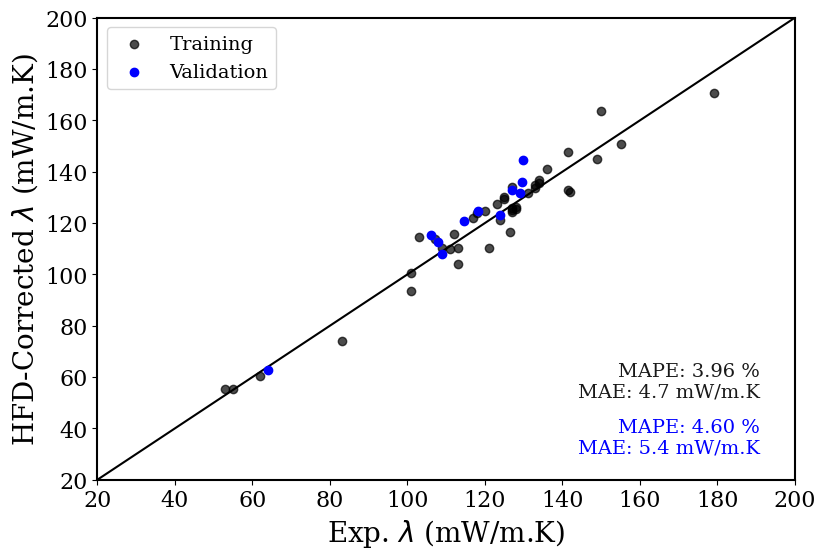

In [12]:

plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})

# 1. Create the figure and axis explicitly to ensure ax.transAxes works
fig, ax = plt.subplots(figsize=(9, 6))

v_ = np.linspace(20, 200, 100)
w_ = v_
# 2. Plotting
ax.plot(w_, v_, color='black', zorder=1)
ax.scatter(tc_exp_train, tc_pred_train, color='black', alpha=0.7, label='Training', zorder=2)
ax.scatter(tc_exp_val, tc_pred_val, color='blue', label='Validation', zorder=3)

# 3. Formatting
ax.set_ylabel(r'HFD-Corrected $\lambda$ (mW/m.K)', fontsize=20)
ax.set_xlabel(r'Exp. $\lambda$ (mW/m.K)', fontsize=20)
ax.set_ylim(20, 200)
ax.set_xlim(20, 200)
ax.tick_params(axis='both', which='major', labelsize=16)



train_metrics = evaluate_output(tc_exp_train, tc_pred_train)
print(train_metrics)

val_metrics = evaluate_output(tc_exp_val, tc_pred_val)
print(val_metrics)



# Define the strings separately
train_text = (
    f"MAPE: {train_metrics[1]:.2f} %\n"
    f"MAE: {train_metrics[2]:.1f} mW/m.K"
)

val_text = (
    f"MAPE: {val_metrics[1]:.2f} %\n"
    f"MAE: {val_metrics[2]:.1f} mW/m.K"
)


# 4. Adding Text Metrics (Inside the plot)
x_pos = 0.95  # Keeps text 5% away from the right spine
y_base = 0.05 # Bottom anchor
gap = 0.12    # Space between blocks

# Validation Metrics - Blue
ax.text(x_pos, y_base, val_text, 
        transform=ax.transAxes, 
        fontsize=14,
        color='blue',
        verticalalignment='bottom', 
        horizontalalignment='right')

# Training Metrics - Gray/Black (with the gap)
ax.text(x_pos, y_base + gap, train_text, 
        transform=ax.transAxes, 
        fontsize=14,
        color='black',
        alpha=0.9, # Grayish effect
        verticalalignment='bottom', 
        horizontalalignment='right')

ax.legend(loc='upper left', frameon=True, fontsize=14)

# 5. Save with tight layout to ensure text is captured
plt.savefig("HFD_corr_TC_Train_Val.png", dpi=500, bbox_inches='tight')

plt.show()


(0.8246482147318404, 3.0687993718070143, 4.2401366938319045, 5.367930258909036)
(-35.51773281417989, 55.47591685337237, 75.75464371685646, 77.46466948368251)


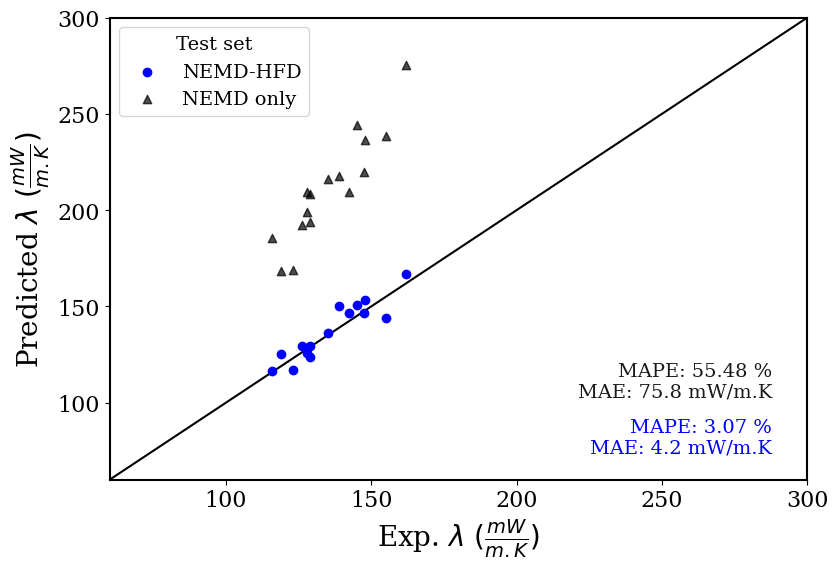

In [13]:


# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(9, 6))

# 2. Plotting
v_ = np.linspace(60, 300, 100)
w_ = v_
ax.plot(w_, v_, color='black', zorder=1)
ax.scatter(tc_exp_test, tc_pred_test, color='blue', label='NEMD-HFD')
ax.scatter(tc_exp_test, tc_hfd_extracted_test[4], color='black', marker='^', alpha=0.7, label='NEMD only')

# 3. Axis Formatting
ax.set_ylabel(r'Predicted $\lambda$ $(\frac{mW}{m.K})$', fontsize=20)
ax.set_xlabel(r'Exp. $\lambda$ $(\frac{mW}{m.K})$', fontsize=20)
ax.set_ylim(60, 300)
ax.set_xlim(60, 300)
ax.tick_params(axis='both', which='major', labelsize=16)



HFD_test_metrics = evaluate_output(tc_exp_test, tc_pred_test)
print(HFD_test_metrics)
NEMDonly_test_metrics = evaluate_output(tc_exp_test, tc_hfd_extracted_test[4])
print(NEMDonly_test_metrics)



# Define the strings separately
NEMD_HFD_text = (
    f"MAPE: {HFD_test_metrics[1]:.2f} %\n"
    f"MAE: {HFD_test_metrics[2]:.1f} mW/m.K"
)

NEMD_only_text = (
    f"MAPE: {NEMDonly_test_metrics[1]:.2f} %\n"
    f"MAE: {NEMDonly_test_metrics[2]:.1f} mW/m.K"
)



# 4. Adding Text Metrics (Inside the plot)
x_pos = 0.95  # Keeps text 5% away from the right spine
y_base = 0.05 # Bottom anchor
gap = 0.12    # Space between blocks

# NEMD-HFD Metrics - Blue
ax.text(x_pos, y_base, NEMD_HFD_text, 
        transform=ax.transAxes, 
        fontsize=14,
        color='blue',
        verticalalignment='bottom', 
        horizontalalignment='right')

# NEMD only Metrics - Gray/Black (Placed above)
ax.text(x_pos, y_base + gap, NEMD_only_text, 
        transform=ax.transAxes, 
        fontsize=14,
        color='black',
        alpha=0.9,
        verticalalignment='bottom', 
        horizontalalignment='right')

# 5. Legend and Saving
ax.legend(loc='upper left', frameon=True, title="Test set", title_fontsize=14, fontsize=14)

plt.savefig("HFD_corr_TC_Testing.png", dpi=500, bbox_inches='tight')
plt.show()


(-0.819162379624522, 5.880123428121642, 8.0641390770891, 9.817231552924254)


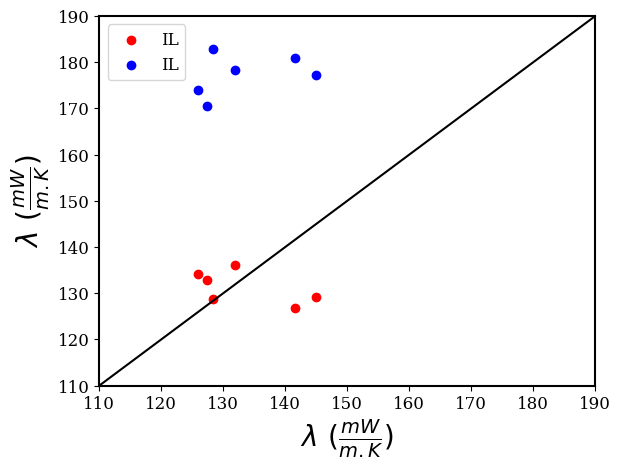

In [14]:

tc_hfd_IL = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="data_tc_hfd_IL")
tc_hfd_extracted_IL =   extract_hfdcorr_data(tc_hfd_IL.iloc[0:,:], 0.003)

num_non_h_IL = tc_hfd_extracted_IL[10]
num_h_IL = tc_hfd_extracted_IL[9]
fbond_IL = tc_hfd_extracted_IL[0]
fangle_IL = tc_hfd_extracted_IL[1]
fintermol_IL = tc_hfd_extracted_IL[11]

y_fit_IL=sum_power_law_bigger((num_non_h_IL, num_h_IL, fbond_IL, fangle_IL, fintermol_IL), a1, b1, a2, b2, a3, b3, c1, c2, d1, d2)


tc_pred_IL = tc_hfd_extracted_IL[4]/(1 + y_fit_IL)
tc_exp_IL = tc_hfd_extracted_IL[6]
v_ = np.linspace(110, 190, 100)
w_ = v_
plt.figure()
plt.plot(w_, v_, color='black')
plt.scatter( tc_exp_IL[0:-1], tc_pred_IL[0:-1], color='red' , label='IL')
plt.scatter( tc_exp_IL[0:-1], tc_hfd_extracted_IL[4][0:-1], color='blue' , label='IL')
plt.legend()
plt.ylabel(r'$\lambda$' ' ' r'$(\frac{mW}{m.K})$', fontsize=20, fontweight='bold')
plt.xlabel(r'$\lambda$' ' ' r'$(\frac{mW}{m.K})$', fontsize=20, fontweight='bold')
plt.ylim(110, 190)
plt.xlim(110, 190)


IL_metrics = evaluate_output(tc_exp_IL[0:-1], tc_pred_IL[0:-1])

print(IL_metrics)



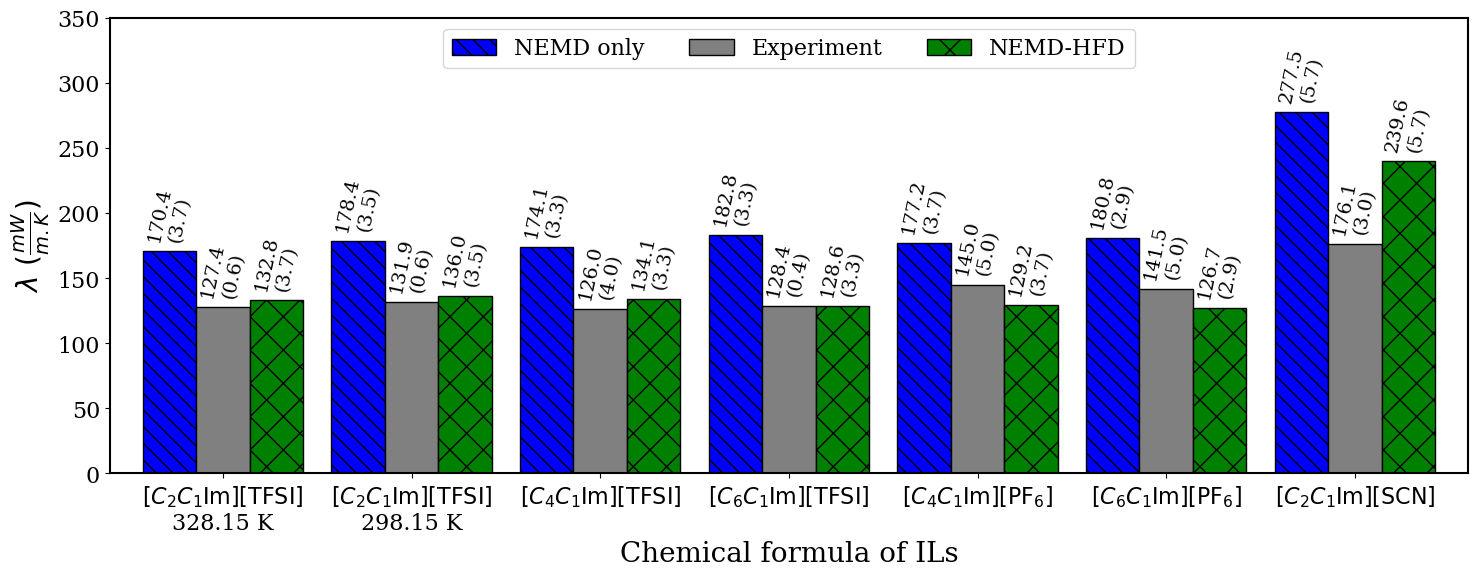

In [15]:


plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 14,
    "axes.linewidth": 1.5
})

plt.figure(figsize=(15, 6))



categories = [
    r'$[C_2C_1\mathrm{Im}][\mathrm{TFSI}]$' + '\n328.15 K',
    r'$[C_2C_1\mathrm{Im}][\mathrm{TFSI}]$' + '\n298.15 K',
    r'$[C_4C_1\mathrm{Im}][\mathrm{TFSI}]$',
    r'$[C_6C_1\mathrm{Im}][\mathrm{TFSI}]$',
    r'$[C_4C_1\mathrm{Im}][\mathrm{PF_6}]$',
    r'$[C_6C_1\mathrm{Im}][\mathrm{PF_6}]$',
    r'$[C_2C_1\mathrm{Im}][\mathrm{SCN}]$'
]

data = {
    'NEMD only': tc_hfd_extracted_IL[4],
    'Experiment': tc_exp_IL,
    'NEMD-HFD':  tc_pred_IL
}

# Uncertainty arrays
all_errors = [
    tc_hfd_extracted_IL[5],      # NEMD only error
    tc_hfd_extracted_IL[7] / 2,  # Experiment error
    tc_hfd_extracted_IL[5]       # NEMD-HFD error
]
#frac_bond, frac_angle, frac_dihed, frac_over, tc_md, tc_md_err, exp_data, exp_unc, num_sites, num_h_atoms, num_non_h_sites, frac_vdwCoul, frac_convec, fin_total, fin_total_ce, fin_imposed         


x = np.arange(len(categories))        # base positions
n_groups = len(data)                  # number of bars per category
total_cluster_width = 0.85
width = total_cluster_width  / n_groups                # total cluster width = 80%

colors = [ 'blue', 'gray', 'green']
hatches = [ '\\\\', None, 'x' ]

# Loop through each model group
for i, ((label, values), color, hatch) in enumerate(zip(data.items(), colors, hatches)):
    offset = (i - (n_groups - 1) / 2) * width
    bars = plt.bar(x + offset, values, width, label=label, 
                   color=color, hatch=hatch, edgecolor='black')

    # Add "Value (Error)" labels on top of each bar
    current_errors = all_errors[i]
    for j, bar in enumerate(bars):
        height = bar.get_height()
        err_val = current_errors[j]
        
        # Combine value and error into one string
        label_text = f'{height:.1f}\n({err_val:.1f})'
        
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height + 3,           # Position 3 units above the bar
            label_text, 
            ha='center', 
            va='bottom', 
            rotation=78,          # Rotated as requested
            fontsize=14, 
            color='black'
        )

# Labels
plt.xticks(x, categories, rotation=0, ha='center')
plt.ylabel(r'$\lambda$' ' ' r'$(\frac{mW}{m.K})$', fontsize=20, fontweight='bold')
plt.xlabel(r'Chemical formula of ILs', fontsize=20)

# Legend on top
plt.legend(
    loc='upper center',
    fontsize=16, 
    ncol=3
)

plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.ylim(0, 350)
plt.xlim(x[0] - 0.6, x[-1] + 0.6)

plt.tight_layout()

plt.savefig("ILs_TC_NEMDonly_NEMD-HFD_all", dpi=500, bbox_inches='tight')

plt.show()


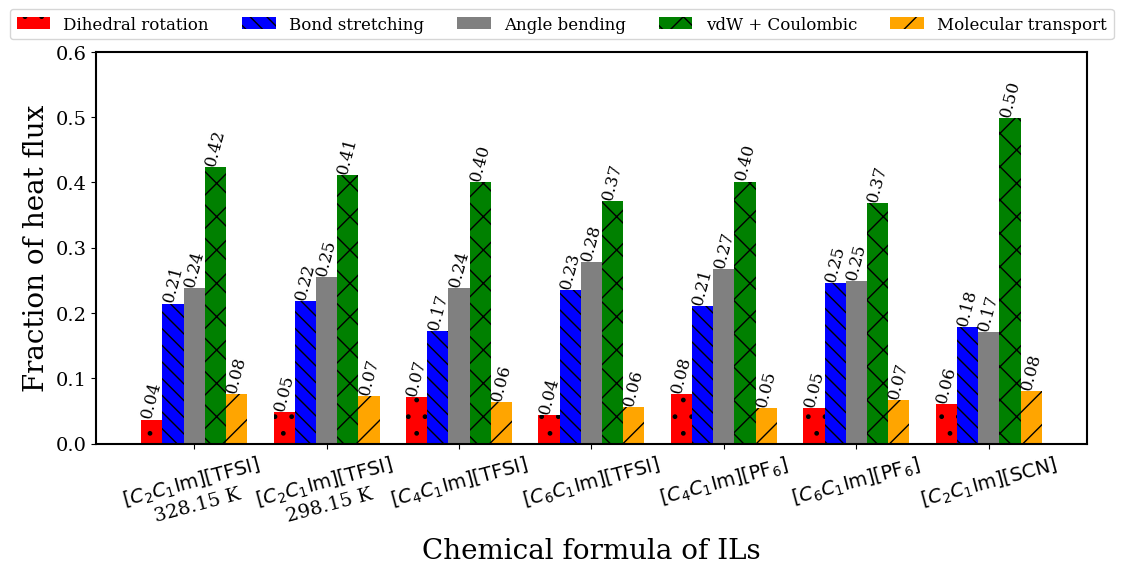

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})

plt.figure(figsize=(12, 6))



categories = [
    r'$[C_2C_1\mathrm{Im}][\mathrm{TFSI}]$' + '\n328.15 K',
    r'$[C_2C_1\mathrm{Im}][\mathrm{TFSI}]$' + '\n298.15 K',
    r'$[C_4C_1\mathrm{Im}][\mathrm{TFSI}]$',
    r'$[C_6C_1\mathrm{Im}][\mathrm{TFSI}]$',
    r'$[C_4C_1\mathrm{Im}][\mathrm{PF_6}]$',
    r'$[C_6C_1\mathrm{Im}][\mathrm{PF_6}]$',
    r'$[C_2C_1\mathrm{Im}][\mathrm{SCN}]$'
]

data_source = tc_hfd_extracted_IL
data = {
    'Dihedral rotation': data_source[2],
    'Bond stretching': data_source[0],
    'Angle bending':  data_source[1],
    'vdW + Coulombic': data_source[11],
    'Molecular transport': data_source[12]  
}

x = np.arange(len(categories))        # base positions
n_groups = len(data)                  # number of bars per category
width = 0.8 / n_groups                # total cluster width = 80%


colors = ['red', 'blue', 'gray', 'green', 'orange']
hatches = ['.', '\\\\', None, 'x', '/']

# Plot bars and add values on top
for i, ((label, values), color, hatch) in enumerate(zip(data.items(), colors, hatches)):
    offset = (i - (n_groups - 1) / 2) * width
    bars = plt.bar(x + offset, values, width, label=label, color=color, hatch=hatch)

        # Add value labels on top of each bar (vertically)
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,  # x-position: center of bar
            height,                           # y-position: top of bar
            f'{height:.2f}',                  # formatted value
            ha='center',                      # horizontal alignment: center
            va='bottom',                       # vertical alignment: bottom (above bar)
            rotation=75,                      # rotate text vertically
            fontsize=12
        )

# Labels
plt.xticks(x, categories, rotation=15, ha='center')
plt.ylabel(r'Fraction of heat flux', fontsize=20)
plt.xlabel(r'Chemical formula of ILs', fontsize=20)

plt.legend(
    loc='upper center',
    fontsize=12, 
    bbox_to_anchor=(0.47, 1.13),
    ncol=5
)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.ylim(0, 0.6)

plt.tight_layout()

plt.savefig("ILs_TC_HFD_all", dpi=500, bbox_inches='tight')

plt.show()



In [17]:
#IL_HFC

In [18]:


tc_hfd_IL_HFC = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="data_tc_hfd_IL_HFC")
tc_hfd_extracted_IL_HFC =   extract_hfdcorr_data(tc_hfd_IL_HFC.iloc[0:,:], 0.0035)

num_non_h_IL_HFC = tc_hfd_extracted_IL_HFC[10]
num_h_IL_HFC = tc_hfd_extracted_IL_HFC[9]
fbond_IL_HFC = tc_hfd_extracted_IL_HFC[0]
fangle_IL_HFC = tc_hfd_extracted_IL_HFC[1]
fintermol_IL_HFC = tc_hfd_extracted_IL_HFC[11]

y_fit_IL_HFC=sum_power_law_bigger((num_non_h_IL_HFC, num_h_IL_HFC, fbond_IL_HFC, fangle_IL_HFC, fintermol_IL_HFC), a1, b1, a2, b2, a3, b3, \
                                  c1, c2, d1, d2)



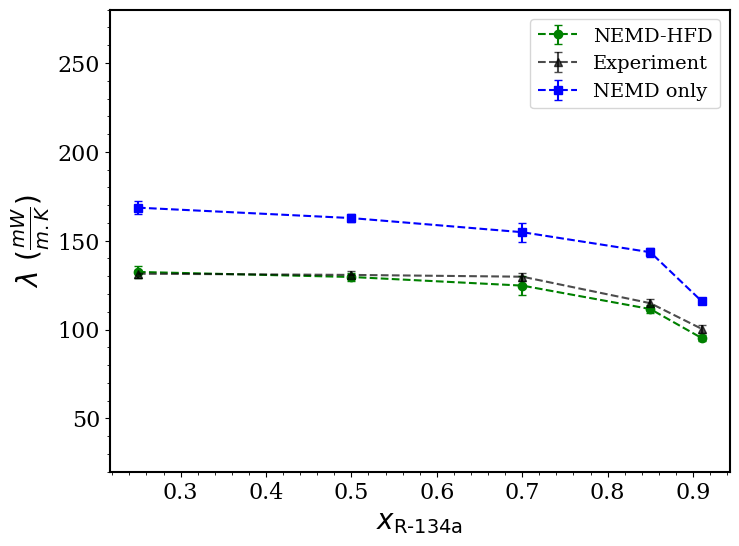

In [19]:

plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})


tc_pred_IL_HFC = tc_hfd_extracted_IL_HFC[4]/(1 + y_fit_IL_HFC)
tc_pred_IL_HFC_err = tc_hfd_extracted_IL_HFC[5]

tc_exp_IL_HFC = tc_hfd_extracted_IL_HFC[6]
tc_exp_IL_HFC_err = tc_hfd_extracted_IL_HFC[7]

hfc_comp = tc_hfd_IL_HFC.iloc[:,7]



fig, ax = plt.subplots(figsize=(8, 6))



ax.errorbar( hfc_comp, tc_pred_IL_HFC, yerr = tc_pred_IL_HFC_err, \
            ecolor = 'green', color='green', fmt='o--', label='NEMD-HFD', capsize=3)

ax.errorbar( hfc_comp, tc_exp_IL_HFC, yerr = tc_exp_IL_HFC_err, \
            ecolor = 'black', color='black', alpha=0.7, fmt='^--', label='Experiment', capsize=3)

ax.errorbar( hfc_comp, tc_hfd_extracted_IL_HFC[4], yerr = tc_pred_IL_HFC_err, \
            ecolor = 'blue', color='blue', fmt='s--', label='NEMD only', capsize=3)
plt.legend(fontsize=14)
plt.ylabel(r'$\lambda$' ' ' r'$(\frac{mW}{m.K})$', fontsize=20, fontweight='bold')
plt.xlabel(r'$x_{\mathrm{R}\text{-}\mathrm{134a}}$', fontsize=20, fontweight='bold')

plt.ylim(20,280)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
ax.minorticks_on()

plt.savefig("ILs_HFC_Mixture_TC_HFD", dpi=500, bbox_inches='tight')

plt.show()



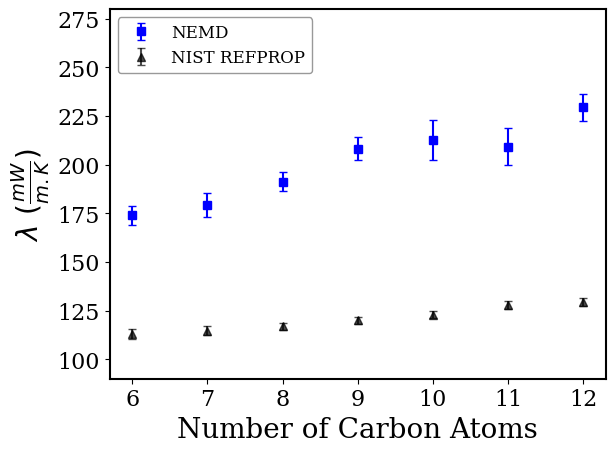

In [20]:

# Alkanes_sameT ILs_sameT

plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})

tc_hfd_alkanes_sameT = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="Alkanes_sameT")
num_C_atoms = tc_hfd_alkanes_sameT.iloc[:, -1]
tc_hfd_extracted_alkanes_sameT =   extract_hfdcorr_data(tc_hfd_alkanes_sameT.iloc[0:,:], 0.003)
tc_hfd_extracted_alkanes_sameT_MD = tc_hfd_extracted_alkanes_sameT[4]
tc_hfd_extracted_alkanes_sameT_MD_err = tc_hfd_extracted_alkanes_sameT[5] 
tc_hfd_extracted_alkanes_sameT_Exp = tc_hfd_extracted_alkanes_sameT[6]
tc_hfd_extracted_alkanes_sameT_Exp_err = (tc_hfd_extracted_alkanes_sameT[6] * tc_hfd_extracted_alkanes_sameT[7])/2
# return frac_bond, frac_angle, frac_dihed, frac_over, tc_md, tc_md_err, exp_data, exp_unc, num_sites, num_h_atoms, num_non_h_sites, frac_vdwCoul, frac_convec, fin_total, fin_total_ce, fin_imposed         

fig, ax = plt.subplots()

ax.errorbar(num_C_atoms, tc_hfd_extracted_alkanes_sameT_MD, yerr = tc_hfd_extracted_alkanes_sameT_MD_err, fmt='s',ecolor = 'blue',color='blue', label = 'NEMD', capsize=3)
ax.errorbar(num_C_atoms, tc_hfd_extracted_alkanes_sameT_Exp, yerr = tc_hfd_extracted_alkanes_sameT_Exp_err, fmt='^',ecolor = 'black',color='black', alpha=0.7, label = 'NIST REFPROP', capsize=3)

plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
#ax.minorticks_on()
plt.xlabel('Number of Carbon Atoms', fontsize=20)
plt.ylabel(r'$\lambda$' ' ' r'$(\frac{mW}{m.K})$', fontsize=20, fontweight='bold')

#  Customizing the legend appearance
ax.legend(loc='upper left',           # 'best' automatically finds an empty spot
           fontsize=12, 
           frameon=True,         # Set to False for a cleaner look without a box
           edgecolor='gray',  # Matches the box border to the plot style
           fancybox=True)        # Rounded corners for the box

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.ylim(90, 280)

plt.savefig("Alkanes_TC_sameT", dpi=500, bbox_inches='tight')


In [21]:
tc_hfd_extracted_alkanes_sameT_MD

array([173.99718339, 179.24513723, 191.34205469, 208.20819845,
       212.74732454, 209.25995751, 229.44743   ])

In [22]:
tc_hfd_extracted_alkanes_sameT_Exp

0    113.0
1    114.7
2    117.0
3    120.0
4    123.0
5    128.0
6    129.5
Name: Ref/Exp Data, dtype: float64

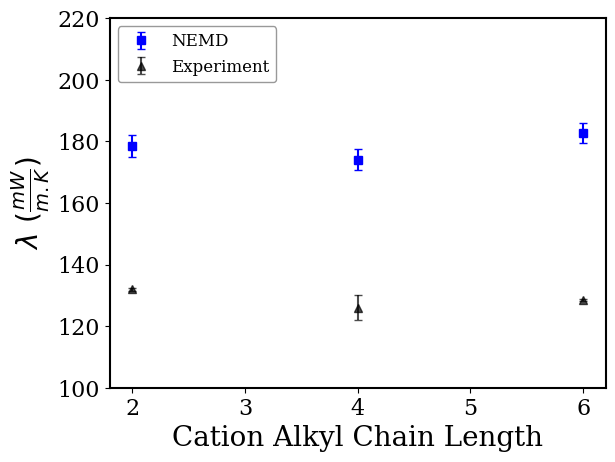

In [23]:

plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})

# Alckanes_sameT ILs_sameT

tc_hfd_ILs_sameT = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="ILs_sameT")
num_C_atoms = tc_hfd_ILs_sameT.iloc[:, -1]
tc_hfd_extracted_ILs_sameT =   extract_hfdcorr_data(tc_hfd_ILs_sameT.iloc[0:,:], 0.003)
tc_hfd_extracted_ILs_sameT_MD = tc_hfd_extracted_ILs_sameT[4]
tc_hfd_extracted_ILs_sameT_MD_err = tc_hfd_extracted_ILs_sameT[5]
tc_hfd_extracted_ILs_sameT_Exp = tc_hfd_extracted_ILs_sameT[6]
tc_hfd_extracted_ILs_sameT_Exp_err = tc_hfd_extracted_ILs_sameT[7]/2
# return frac_bond, frac_angle, frac_dihed, frac_over, tc_md, tc_md_err, exp_data, exp_unc, num_sites, num_h_atoms, num_non_h_sites, frac_vdwCoul 11, frac_convec 12, fin_total, fin_total_ce, fin_imposed         

fig, ax = plt.subplots()

ax.errorbar(num_C_atoms, tc_hfd_extracted_ILs_sameT_MD, yerr = tc_hfd_extracted_ILs_sameT_MD_err, fmt='s',ecolor = 'blue',color='blue', label = 'NEMD', capsize=3)
ax.errorbar(num_C_atoms, tc_hfd_extracted_ILs_sameT_Exp, yerr = tc_hfd_extracted_ILs_sameT_Exp_err, fmt='^',ecolor = 'black',color='black', alpha=0.7, label = 'Experiment', capsize=3)

plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
#ax.minorticks_on()
plt.xlabel('Cation Alkyl Chain Length', fontsize=20)
plt.ylabel(r'$\lambda$' ' ' r'$(\frac{mW}{m.K})$', fontsize=20, fontweight='bold')

#  Customizing the legend appearance
ax.legend(loc='upper left',           # 'best' automatically finds an empty spot
           fontsize=12, 
           frameon=True,         # Set to False for a cleaner look without a box
           edgecolor='gray',  # Matches the box border to the plot style
           fancybox=True)        # Rounded corners for the box

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.ylim(100, 220)

plt.savefig("ILs_TC_sameT", dpi=500, bbox_inches='tight')


In [24]:

split_indices = [0, 2, 4, 6]
data_source = tc_hfd_extracted_alkanes_sameT
a = data_source[11][split_indices]



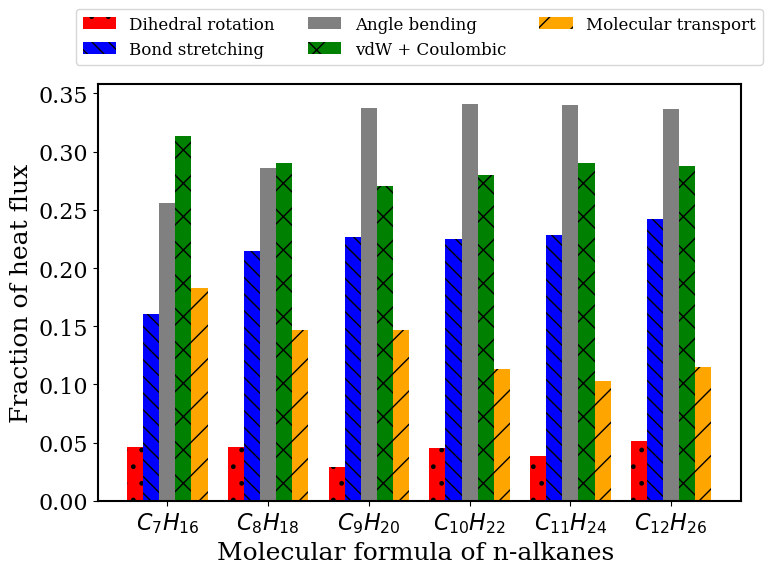

In [25]:


plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})

plt.figure(figsize=(8, 6))


#categories = [r'$C_6H_{14}$', r'$C_8H_{18}$', r'$C_10H_{22}$', r'$C_12H_{26}$']
categories = [ r'$C_7H_{16}$', r'$C_8H_{18}$', r'$C_9H_{20}$', r'$C_{10}H_{22}$', r'$C_{11}H_{24}$', r'$C_{12}H_{26}$']
split_indices = [ 1, 2, 3, 4, 5, 6]
data_source = tc_hfd_extracted_alkanes_sameT
data = {
    'Dihedral rotation': data_source[2][split_indices],
    'Bond stretching': data_source[0][split_indices],
    'Angle bending':  data_source[1][split_indices],
    'vdW + Coulombic': data_source[11][split_indices],
    'Molecular transport': data_source[12][split_indices]  
}

x = np.arange(len(categories))        # base positions
n_groups = len(data)                  # number of bars per category
width = 0.8 / n_groups                # total cluster width = 80%


colors = ['red', 'blue', 'gray', 'green', 'orange']
hatches = ['.', '\\\\', None, 'x', '/']

# Plot
for i, ((label, values), color, hatch) in enumerate(zip(data.items(), colors, hatches)):
    offset = (i - (n_groups - 1) / 2) * width
    plt.bar(x + offset, values, width, label=label, color=color, hatch=hatch)

# Labels
plt.xticks(x, categories)
plt.ylabel(r'Fraction of heat flux', fontsize=18)
plt.xlabel(r'Molecular formula of n-alkanes ', fontsize=18)
plt.legend(
    loc='upper center',
    fontsize=12, 
    bbox_to_anchor=(0.5, 1.20),
    ncol=3
)

plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.tight_layout()

plt.savefig("n-alkanes_TC_sameT_HFD", dpi=500, bbox_inches='tight')

plt.show()



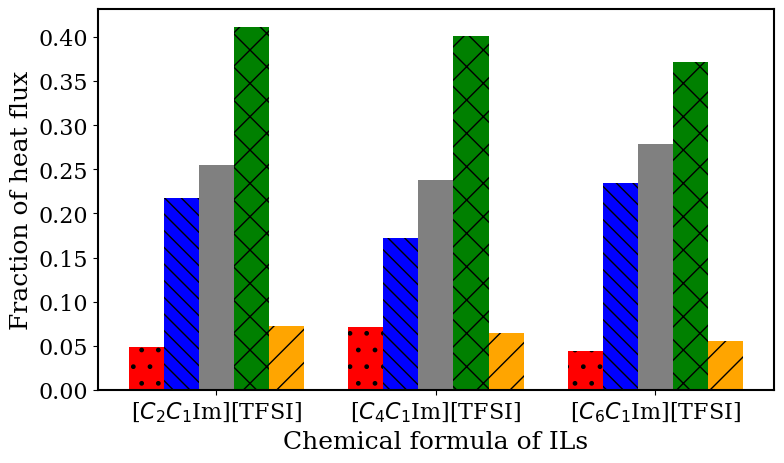

In [26]:


plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})

plt.figure(figsize=(8, 4.8))
# Data
#frac_vdwCoul 11, frac_convec 12
# frac_bond 0, frac_angle 1, frac_dihed 2, frac_over 3

#categories = [r'$C_6H_{14}$', r'$C_8H_{18}$', r'$C_10H_{22}$', r'$C_12H_{26}$']
categories = [ r'[$C_2C_1$Im][TFSI]', r'[$C_4C_1$Im][TFSI]', r'[$C_6C_1$Im][TFSI]']
split_indices = [ 0, 1, 2]
data_source = tc_hfd_extracted_ILs_sameT
data = {
    'Dihedral rotation': data_source[2][split_indices],
    'Bond stretching': data_source[0][split_indices],
    'Angle bending':  data_source[1][split_indices],
    'vdW + Coulombic': data_source[11][split_indices],
    'Molecular transport': data_source[12][split_indices]  
}

x = np.arange(len(categories))        # base positions
n_groups = len(data)                  # number of bars per category
width = 0.8 / n_groups                # total cluster width = 80%


colors = ['red', 'blue', 'gray', 'green', 'orange']
hatches = ['.', '\\\\', None, 'x', '/']

# Plot
for i, ((label, values), color, hatch) in enumerate(zip(data.items(), colors, hatches)):
    offset = (i - (n_groups - 1) / 2) * width
    plt.bar(x + offset, values, width, label=label, color=color, hatch=hatch)

# Labels
plt.xticks(x, categories)
plt.ylabel(r'Fraction of heat flux', fontsize=18)
plt.xlabel(r'Chemical formula of ILs', fontsize=18)



plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.tight_layout()

plt.savefig("ILs_TC_sameT_HFD", dpi=500, bbox_inches='tight')

plt.show()



In [27]:
%%time
tc_hfd_all = pd.read_excel("data_tc_hfd_all.xlsx", sheet_name="data_tc_hfd_full")
tc_hfd_extracted_all = extract_hfdcorr_data(tc_hfd_all.iloc[0:,:], 0.003)


CPU times: total: 641 ms
Wall time: 643 ms


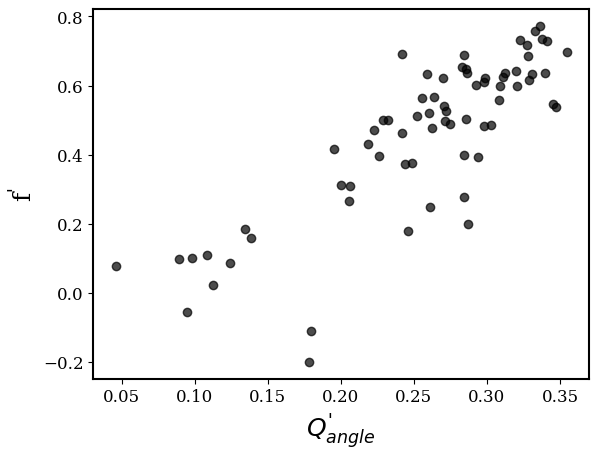

In [28]:

plt.rcParams.update({
    "text.usetex": False, # Set to True if you have LaTeX installed
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5
})


frac_over_all = tc_hfd_extracted_all[3]
frac_hfd_angle = tc_hfd_extracted_all[1]

plt.plot(frac_hfd_angle, frac_over_all, color='black', alpha=0.7, marker='o', linestyle='None')
plt.ylabel(r"f$^'$", fontsize=18)
plt.xlabel(r"$Q^'_{angle}$", fontsize=18)

plt.savefig("frac_over_vs_Qangle", dpi=500, bbox_inches='tight')


In [29]:
frac_over_all[-10:]

60    0.275810
61    0.177256
62    0.198574
63    0.246948
64    0.265378
65    0.309800
66    0.310388
67    0.545176
68    0.634843
69    0.758041
Name: Ref/Exp Data, dtype: float64

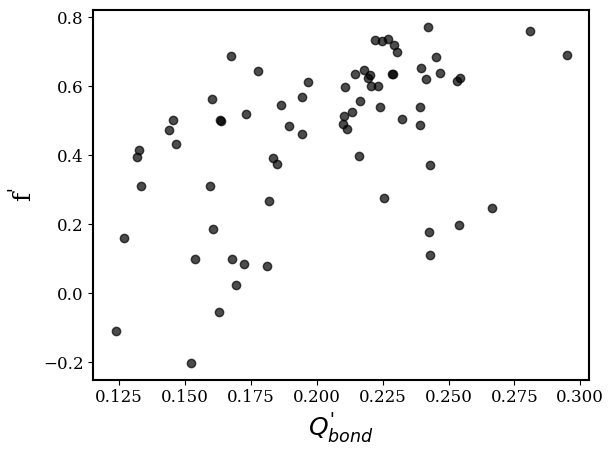

In [30]:

frac_hfd_bond = tc_hfd_extracted_all[0]

plt.plot(frac_hfd_bond, frac_over_all, color='black', alpha=0.7, marker='o', linestyle='None')
plt.ylabel(r"f$^'$", fontsize=18)
plt.xlabel(r"$Q^'_{bond}$", fontsize=18)

plt.savefig("frac_over_vs_Qbond", dpi=500, bbox_inches='tight')


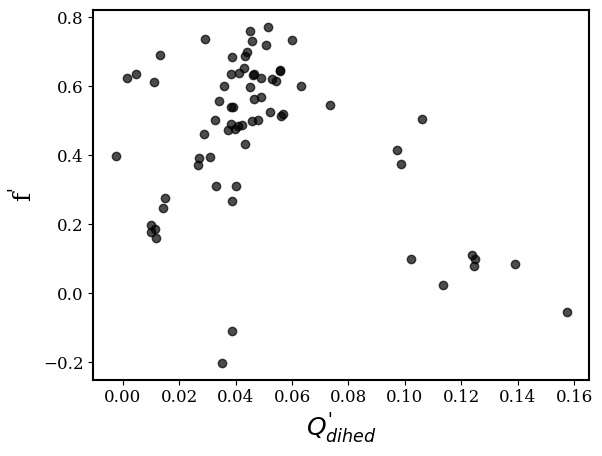

In [31]:

frac_hfd_dihed = tc_hfd_extracted_all[2]

plt.plot(frac_hfd_dihed, frac_over_all, color='black', alpha=0.7, marker='o', linestyle='None')
plt.ylabel(r"f$^'$", fontsize=18)
plt.xlabel(r"$Q^'_{dihed}$", fontsize=18)

plt.savefig("frac_over_vs_Qdihed", dpi=500, bbox_inches='tight')


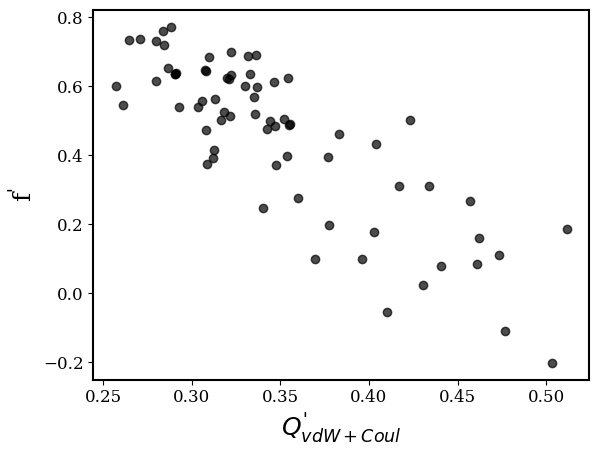

In [32]:

frac_hfd_vdWCoul = tc_hfd_extracted_all[11]

plt.plot(frac_hfd_vdWCoul, frac_over_all, color='black', alpha=0.7, marker='o', linestyle='None')
plt.ylabel(r"f$^'$", fontsize=18)
plt.xlabel(r"$Q^'_{vdW+Coul}$", fontsize=18)

plt.savefig("frac_over_vs_QvdWCoul", dpi=500, bbox_inches='tight')


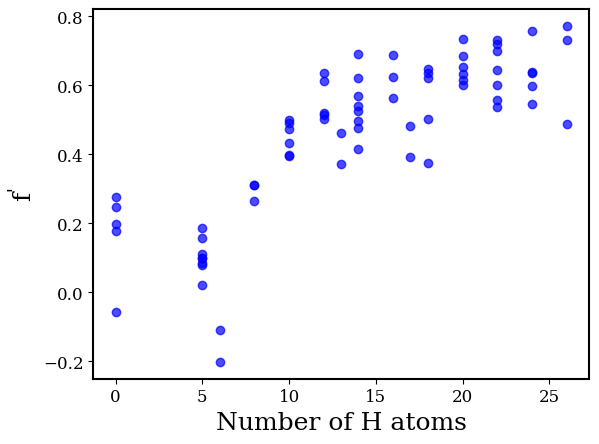

In [33]:
num_h_sites = tc_hfd_extracted_all[9]

plt.plot(num_h_sites, frac_over_all, color='blue', alpha=0.7, marker='o', linestyle='None')
plt.ylabel(r"f$^'$", fontsize=18)
plt.xlabel("Number of H atoms", fontsize=18)

plt.savefig("frac_over_vs_numHsites", dpi=500, bbox_inches='tight')


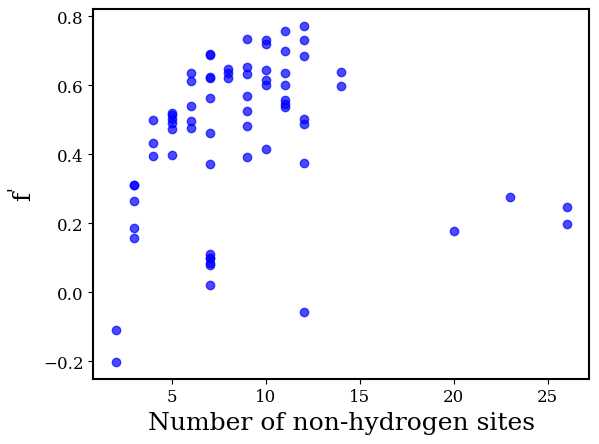

In [34]:

num_non_h_sites = tc_hfd_extracted_all[10]

plt.plot(num_non_h_sites, frac_over_all, color='blue', alpha=0.7, marker='o', linestyle='None')
plt.ylabel(r"f$^'$", fontsize=18)
plt.xlabel("Number of non-hydrogen sites" , fontsize=18)
           
plt.savefig("frac_over_vs_num_non_Hsites", dpi=500, bbox_inches='tight')
           